### Data Explorer
Tasks
- Preprocessing
    - Finding structure scenarios
    - Splitting coordinates into rows (for each player during event)
- Plotting
    - puck control
    - position of defensive players
    - passes
    - shots

In [36]:
## Import
import urllib.error
import urllib.request
import hockey_rink as hr
import matplotlib.pyplot as plt
import pandas as pd
import os

from PIL.EpsImagePlugin import split

os.listdir()

['(PK) Diamond Shape.png',
 '(PK) Pressure Pushdown (1+Triangle).png',
 '(PK) Protect Inside Box_.png',
 'data_explorer.ipynb',
 'Data_SCFinal.xlsx',
 'PP(5v4)Goals NLA 25-26 (TEST).xlsx',
 'Results &  Questions.docx',
 'Way of Scoring (Data Science).docx']

## Import Data

In [95]:
data_in = pd.read_excel("Data_SCFinal.xlsx", sheet_name="control_example")
data_in

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection3,StartPlayerDirection4,StartPlayerDirection5,StartPlayerDirection6,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12
0,1,1032,1767181288920,BluelineCrossing,HomePowerplay,5v4,True,True,AwayTeamZone,"7.2,11.4",...,"0.954,0.301","0.91,0.415","0.895,0.447","0.741,0.672","0.703,0.711","0.701,0.713","0.618,0.786","0.957,0.291","0.49,0.872",NaN
1,1,1033,1767181290620,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"19,13",...,"0.998,-0.06","0.734,0.679","0.613,-0.79","1,0.014","0.999,-0.045","0.965,-0.26","0.987,0.159","0.763,-0.646","0.762,-0.648",NaN
2,1,1033,1767181290640,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"18.9,13",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1034,1767181291340,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"10.2,14.6",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1037,1767181294600,Dump,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,"0.336,0.942","0.826,0.563","0.021,1","0.381,0.924","0.177,0.984","0.73,-0.684","-0.22,0.976","-0.576,0.818","-0.322,0.947",NaN
5,1,1037,1767181294620,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,1039,1767181296360,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.9,7.5",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,1040,1767181297520,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.3,10.8",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,1041,1767181298560,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"26.7,13.3",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,1045,1767181302300,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"7.9,11.9",...,"-0.814,-0.58","-0.985,-0.173","-0.996,0.085","-0.998,-0.071","-0.999,0.054","-0.972,-0.236","-0.937,-0.348","-0.976,0.217","-0.951,-0.309",NaN


In [97]:
## create dedicated x,y fields for event start, end
data_in[['EventStartX', 'EventStartY']] = (data_in['EventStartCoordinate'].str.split(',', expand=True).astype(float))
data_in[['EventEndX', 'EventEndY']] = (data_in['EventEndCoordinate'].str.split(',', expand=True).astype(float))
data_in = data_in[1:] #remove blue line crossing
data_in

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,EventStartX,EventStartY,EventEndX,EventEndY
2,1,1033,1767181290640,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"18.9,13",...,NaN,NaN,NaN,NaN,NaN,NaN,18.9,13.0,10.2,14.6
3,1,1034,1767181291340,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"10.2,14.6",...,NaN,NaN,NaN,NaN,NaN,NaN,10.2,14.6,8.7,14.5
4,1,1037,1767181294600,Dump,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,"0.177,0.984","0.73,-0.684","-0.22,0.976","-0.576,0.818","-0.322,0.947",NaN,8.7,14.5,29.9,7.6
5,1,1037,1767181294620,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,NaN,NaN,NaN,NaN,NaN,NaN,8.7,14.5,29.9,7.5
6,1,1039,1767181296360,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.9,7.5",...,NaN,NaN,NaN,NaN,NaN,NaN,29.9,7.5,29.3,10.8
7,1,1040,1767181297520,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.3,10.8",...,NaN,NaN,NaN,NaN,NaN,NaN,29.3,10.8,26.7,13.3
8,1,1041,1767181298560,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"26.7,13.3",...,NaN,NaN,NaN,NaN,NaN,NaN,26.7,13.3,7.8,11.8
9,1,1045,1767181302300,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"7.9,11.9",...,"-0.999,0.054","-0.972,-0.236","-0.937,-0.348","-0.976,0.217","-0.951,-0.309",NaN,7.9,11.9,-0.2,-0.5
10,1,1045,1767181302320,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"7.8,11.8",...,NaN,NaN,NaN,NaN,NaN,NaN,7.8,11.8,-0.2,-0.5


In [71]:
pass_row = data_in.loc[4]
x = float(pass_row['EventStartCoordinate'].split(",")[0])
y = float(pass_row['EventStartCoordinate'].split(",")[1])


In [99]:
## arrows for passes function into list
start_coords = pass_row['EventStartCoordinate'].split(",")
start_coords = [float(i) for i in start_coords]
print(start_coords)

end_coords = pass_row['EventEndCoordinate'].split(",")
end_coords = [float(i) for i in end_coords]
print(end_coords)

[8.7, 14.5]
[29.9, 7.6]


## Hockey-Rink

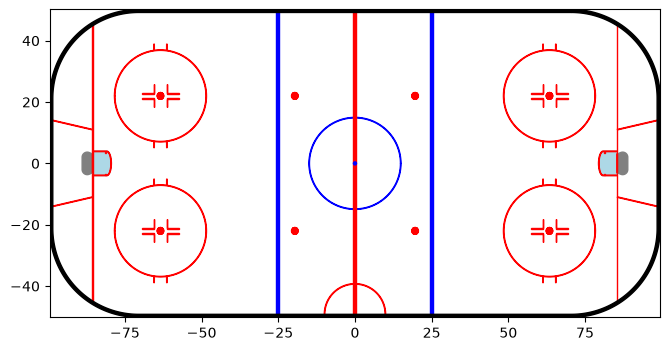

In [111]:
## produce rink drawing
rink = hr.IIHFRink()
rink.draw(figsize=(10, 4), despine = False) #default size 10x4, large is 20x8
plt.show()

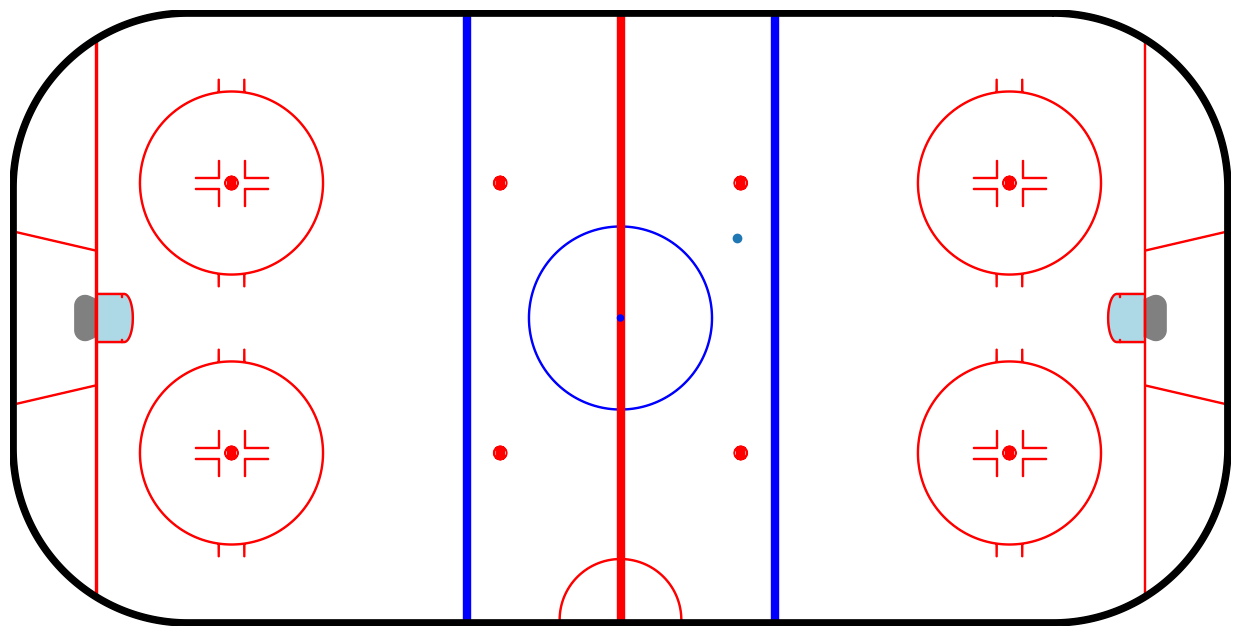

In [56]:
#produce scatter on rink
rink.scatter(x = x,
             y = y,
             draw_kw={"figsize": (20, 8)}
             )
plt.show()

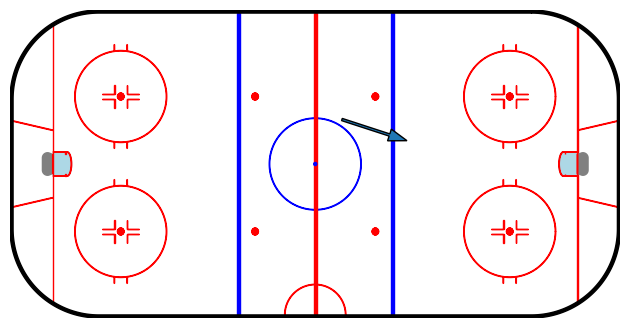

In [76]:
rink.arrow(
    x = start_coords[0],
    y = start_coords[1],

    x2 = end_coords[0],
    y2 = end_coords[1],

    # facecolor="purple", edgecolor="black",
    head_width=4, length_includes_head=True,
    draw_kw={"figsize": (10, 4)},
)
plt.show()

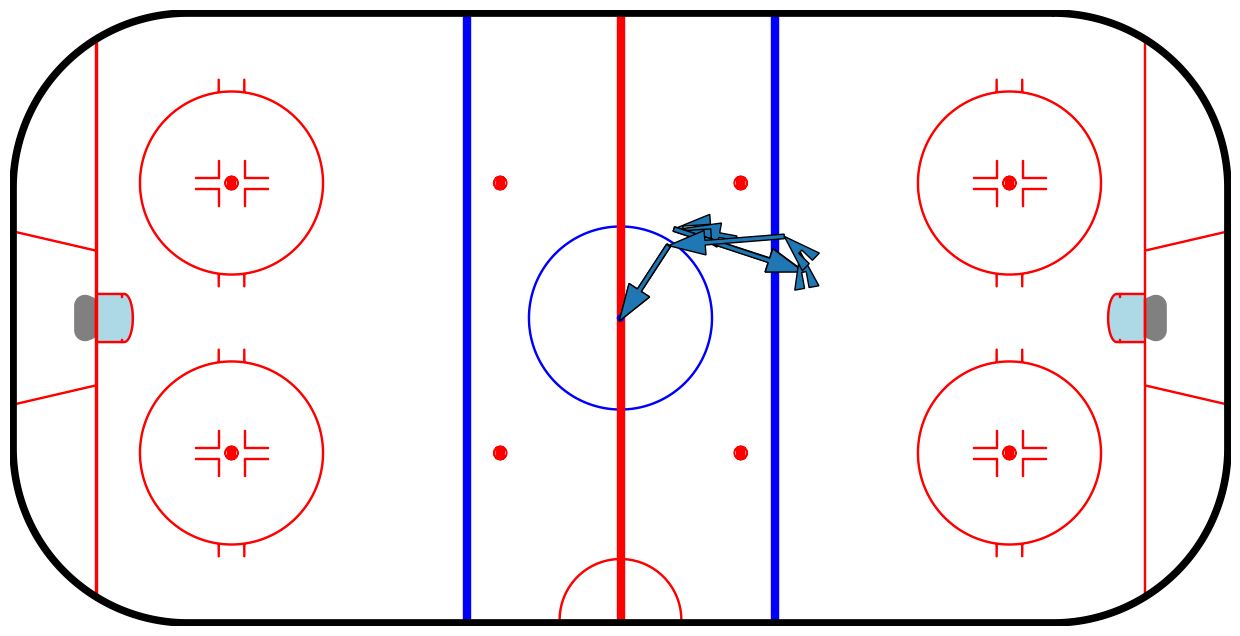

In [101]:
rink.arrow(
    data = data_in,
    x = "EventStartX",
    y = "EventStartY",

    x2 = "EventEndX",
    y2 = "EventEndY",

    # facecolor="purple", edgecolor="black",
    head_width=4, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)
plt.show()

## Use a set up Structure example
3P0:24 to 3P0:58

In [153]:
structure_df = pd.read_excel("Data_SCFinal.xlsx", sheet_name="structure_2")
structure_df[['EventStartX', 'EventStartY']] = (structure_df['EventStartCoordinate'].str.split(',', expand=True).astype(float))
structure_df[['EventEndX', 'EventEndY']] = (structure_df['EventEndCoordinate'].str.split(',', expand=True).astype(float))
structure_df[['EventEndX']] = structure_df[['EventEndX']]*3.28084
structure_df[['EventEndY']] = structure_df[['EventEndY']]*3.28084
structure_df[['EventStartX']] = structure_df[['EventStartX']]*3.28084
structure_df[['EventStartY']] = structure_df[['EventStartY']]*3.28084
structure_df

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,EventStartX,EventStartY,EventEndX,EventEndY
0,3,77,1767185785460,Pass,AwayPowerplay,4v5,True,True,NeutralZone,"-3.8,-6.9",...,"-0.968,-0.252","-0.697,-0.717","0.203,-0.979","-0.809,-0.588","-0.684,-0.729",NaN,-12.467192,-22.637796,-32.480316,-44.291340
1,3,77,1767185785480,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"-4.1,-7",...,NaN,NaN,NaN,NaN,NaN,NaN,-13.451444,-22.965880,-32.480316,-44.291340
2,3,78,1767185786260,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-9.9,-13.5",...,NaN,NaN,NaN,NaN,NaN,NaN,-32.480316,-44.291340,-93.503940,-27.559056
3,3,82,1767185790000,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-28.3,-8.7",...,"-0.999,0.043","-0.997,-0.076","0.035,0.999","-0.454,0.891","-0.655,0.756",NaN,-92.847772,-28.543308,-92.847772,40.682416
4,3,82,1767185790020,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-28.5,-8.4",...,NaN,NaN,NaN,NaN,NaN,NaN,-93.503940,-27.559056,-92.519688,41.010500
5,3,83,1767185791180,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-28.2,12.5",...,NaN,NaN,NaN,NaN,NaN,NaN,-92.519688,41.010500,-94.816276,37.729660
6,3,83,1767185791560,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-28.9,11.5",...,NaN,NaN,NaN,NaN,NaN,NaN,-94.816276,37.729660,-94.160108,36.745408
7,3,83,1767185791880,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-28.7,11.2",...,NaN,NaN,NaN,NaN,NaN,NaN,-94.160108,36.745408,-90.879268,32.480316
8,3,84,1767185792560,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-27.7,10",...,"-0.095,0.996","-0.455,0.891","0.638,0.77","0.166,0.986","0.698,-0.716",NaN,-90.879268,32.808400,-61.023624,-48.884516
9,3,84,1767185792580,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-27.7,9.9",...,NaN,NaN,NaN,NaN,NaN,NaN,-90.879268,32.480316,-61.023624,-48.884516


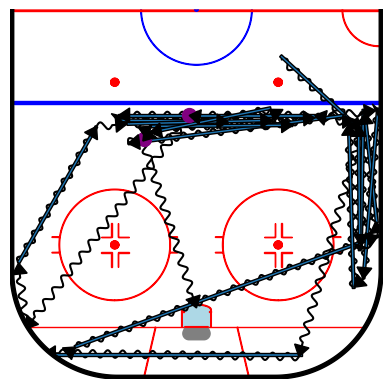

In [154]:
rink.draw(display_range="defence", rotation=90)
rink.wavy_arrow(
    data=structure_df[structure_df["EventType"] == "PuckControl"],
    x="EventStartX",
    y="EventStartY",

    x2="EventEndX",
    y2="EventEndY",

    # facecolor="purple", edgecolor="black",
    head_width=4, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)

rink.arrow(
    data=structure_df[structure_df["EventType"] == "Pass"],
    x="EventStartX",
    y="EventStartY",

    x2="EventEndX",
    y2="EventEndY",


    # facecolor="purple", edgecolor="black",
    head_width=0, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)
rink.scatter(
    data=structure_df[structure_df["EventType"] == "Shot"],
    x="EventStartX",
    y="EventStartY",
    color = "purple",
    s=100
)
plt.show()

Not sure why the Pass (arrow) and Puckcontrol (Squiggle) overlap so much

RuntimeError: Invalid vertices array.

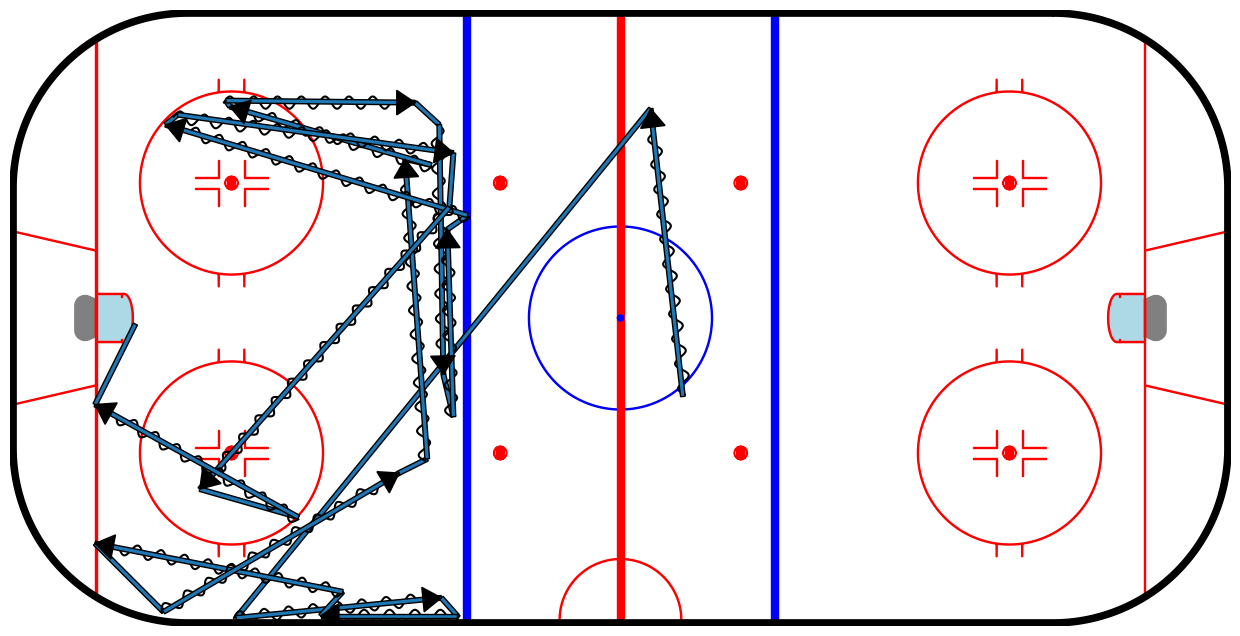

In [149]:
#wanted to see if I could plot these in a loop

for i, row in structure_df.iterrows():
    if row["EventType"] == "Pass":
        rink.wavy_arrow(
            data=row,
            x="EventStartX",
            y="EventStartY",

            x2="EventEndX",
            y2="EventEndY",

            # facecolor="purple", edgecolor="black",
            head_width=4, length_includes_head=True,
            draw_kw={"figsize": (20, 8)},
        )
    else:
        rink.arrow(
            data=row,
            x="EventStartX",
            y="EventStartY",

            x2="EventEndX",
            y2="EventEndY",
             # facecolor="purple", edgecolor="black",
            head_width=0, length_includes_head=True,
            draw_kw={"figsize": (20, 8)},
            )
    plt.show()
